# Predicting High-Income Individuals from Demographic Data


## Dataset Selection

- **Dataset**: UCI Adult Income Dataset  
- **Source**: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult)  
- **Description**: This dataset contains demographic and employment-related information from the 1994 U.S. Census database. The goal is to build a classification model that predicts whether an individual earns more than $50K annually based on attributes like age, education, occupation, and hours worked.


In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [10]:
# Extract column names from adult.names file
with open("adult-data/adult.names", "r") as f:
    lines = f.readlines()

column_names = [
    line.split(":")[0].strip()
    for line in lines
    if ":" in line and not line.startswith("|")
]
column_names.append("income")

# Load dataset
df = pd.read_csv(
    "adult-data/adult.data",
    header=None,
    names=column_names,
    na_values="?",
    skipinitialspace=True
)

# Preview the dataset
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Initial Dataset Overview

### 1. Feature Description

| **Feature**        | **Type**      | **Description**                                                             |
|--------------------|---------------|------------------------------------------------------------------------------|
| `age`              | Numerical     | Age of the individual                                                       |
| `workclass`        | Categorical   | Type of employment (e.g., Private, Self-emp, Government)                    |
| `fnlwgt`           | Numerical     | Final weight (represents how many people the entry represents)             |
| `education`        | Categorical   | Highest level of education (e.g., Bachelors, HS-grad)                       |
| `education-num`    | Numerical     | Number of years of education (numeric version of `education`)              |
| `marital-status`   | Categorical   | Marital status (e.g., Married, Never-married)                               |
| `occupation`       | Categorical   | Type of occupation (e.g., Exec-managerial, Handlers-cleaners)              |
| `relationship`     | Categorical   | Household relationship (e.g., Husband, Not-in-family)                       |
| `race`             | Categorical   | Race (e.g., White, Black, Asian-Pac-Islander)                               |
| `sex`              | Categorical   | Gender (Male or Female)                                                     |
| `capital-gain`     | Numerical     | Income from capital gains (e.g., profit from selling stocks or property)   |
| `capital-loss`     | Numerical     | Capital loss (e.g., money lost in investments)                              |
| `hours-per-week`   | Numerical     | Number of hours worked per week                                             |
| `native-country`   | Categorical   | Country of origin (e.g., United-States, Mexico, India)                      |
| `income`           | Binary        | Target variable: Whether income is >50K or <=50K                            |

---

### 🏷️ Target Variable
- **`income`**: Classification target — values are:
  - `<=50K`: Low income
  - `>50K`: High income

---

### 🗂️ Feature Types Summary
- **Numerical Features**:  
  `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`  
- **Categorical Features**:  
  `workclass`, `education`, `marital-status`, `occupation`, `relationship`,  
  `race`, `sex`, `native-country`


### 2. Dataset Structure


In [12]:
# Display shape of the dataset
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")



Total Rows: 32561
Total Columns: 15


### 3. Missing Values and Duplicates


In [13]:
# Check missing values
df.isna().sum()


age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

### 4. Statistical Summary

This section provides a statistical overview of the numerical features, including count, mean, standard deviation, min, and max values. It helps understand feature distributions and detect potential anomalies such as outliers.


In [14]:
# Summary statistics for numerical columns
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 5. Interpretation of Statistical Summary

Below are key observations from the numerical feature summary:

- **Age**: Ranges from 17 to 90 years, with a median of 37. Most individuals are between 28 and 48.
- **fnlwgt**: Ranges widely (12K to 1.48M) — used for sampling weight in census.
- **Education-num**: Maps to years of education (1–16). Median is 10, most common range is 9–12.
- **Capital-gain** and **Capital-loss**: Many zero values (25%, 50%, and 75% quantiles are all 0), but a few very high outliers — suggesting skewed distribution.
- **Hours-per-week**: Mostly between 40 and 45 hours, with a minimum of 1 and max of 99. Median is exactly 40, indicating a large portion work full-time.

This summary reveals that:
- Many features are skewed or imbalanced (especially capital-gain/loss).
- Age and hours-per-week show more typical bell-shaped distributions.
- Feature scaling and outlier detection will be important in preprocessing.


### 6. Basic Visualizations

Visualizing feature distributions helps us better understand data spread, detect outliers, and observe potential class separations (especially with respect to the income variable).


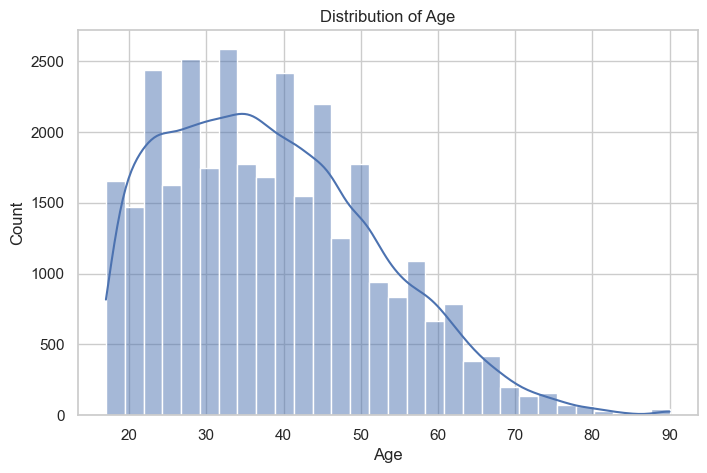

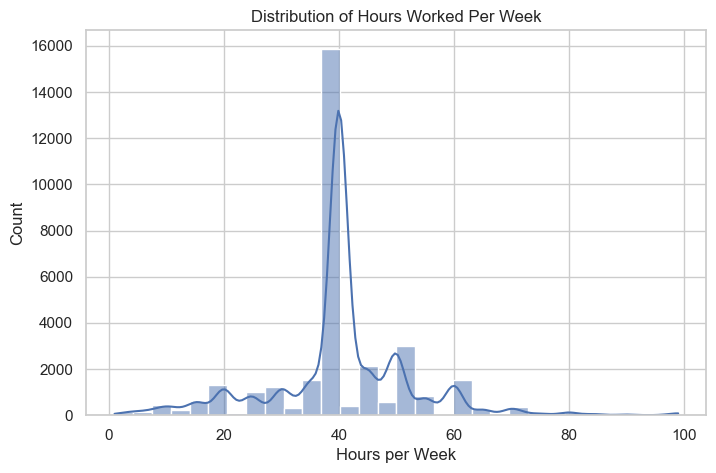

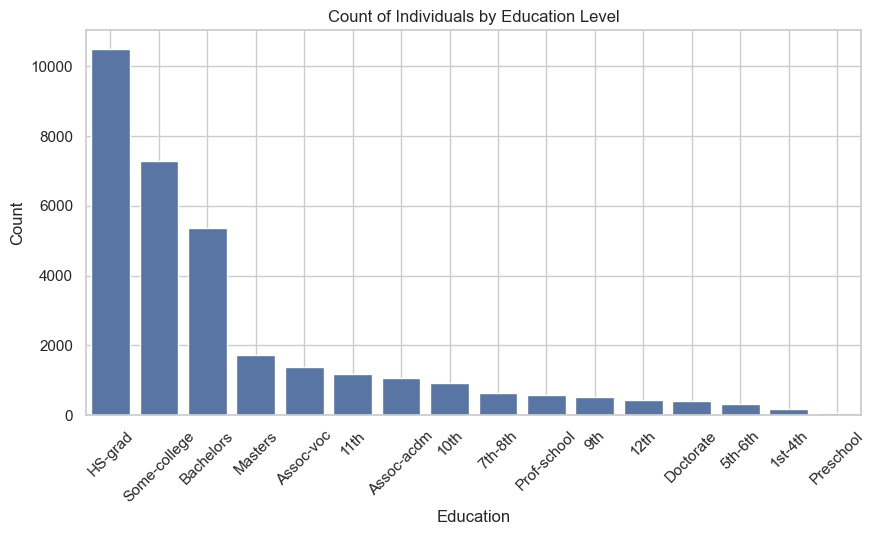

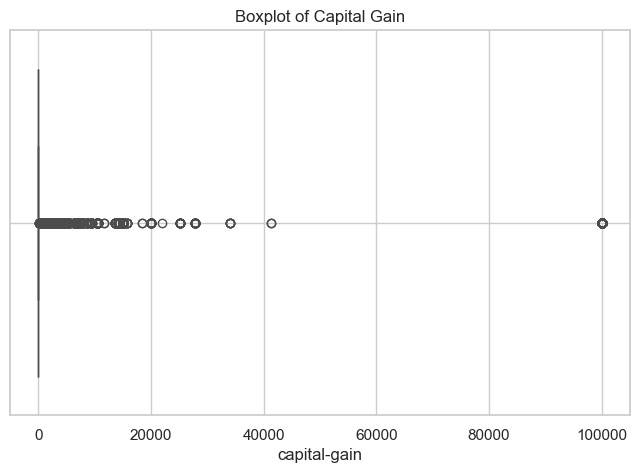

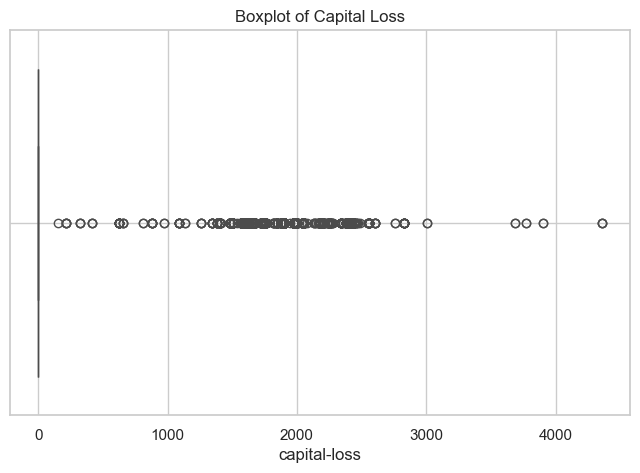

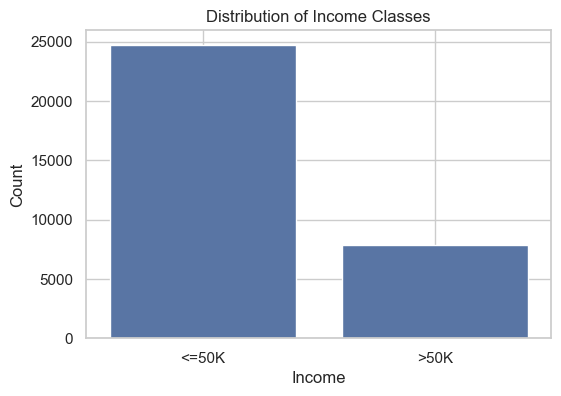

In [28]:
# Age distribution with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Distribution of hours worked per week
plt.figure(figsize=(8, 5))
sns.histplot(df['hours-per-week'], kde=True, bins=30)
plt.title("Distribution of Hours Worked Per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Barplot of education levels
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education', order=df['education'].value_counts().index)
plt.title("Count of Individuals by Education Level")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Education")
plt.grid(True)
plt.show()

# Boxplot for capital gain (to show outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='capital-gain')
plt.title("Boxplot of Capital Gain")
plt.grid(True)
plt.show()

# Boxplot for capital loss (to show outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='capital-loss')
plt.title("Boxplot of Capital Loss")
plt.grid(True)
plt.show()

# Distribution of target variable (income)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='income')
plt.title("Distribution of Income Classes")
plt.xlabel("Income")
plt.ylabel("Count")
plt.grid(True)
plt.show()


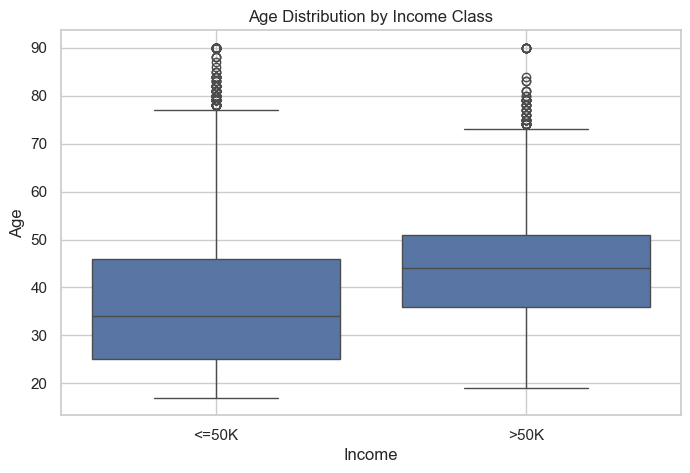

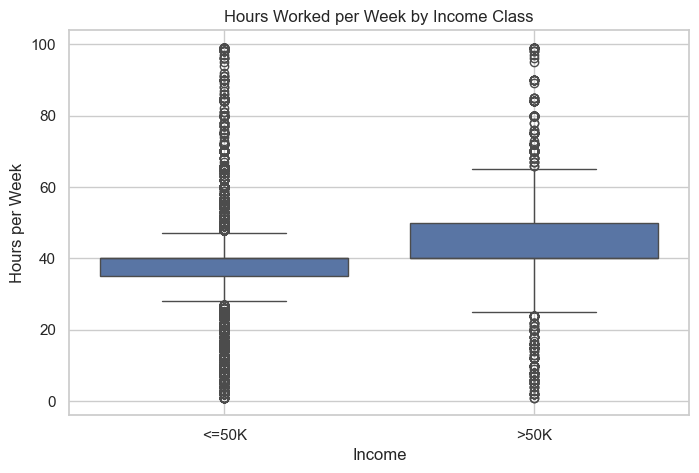

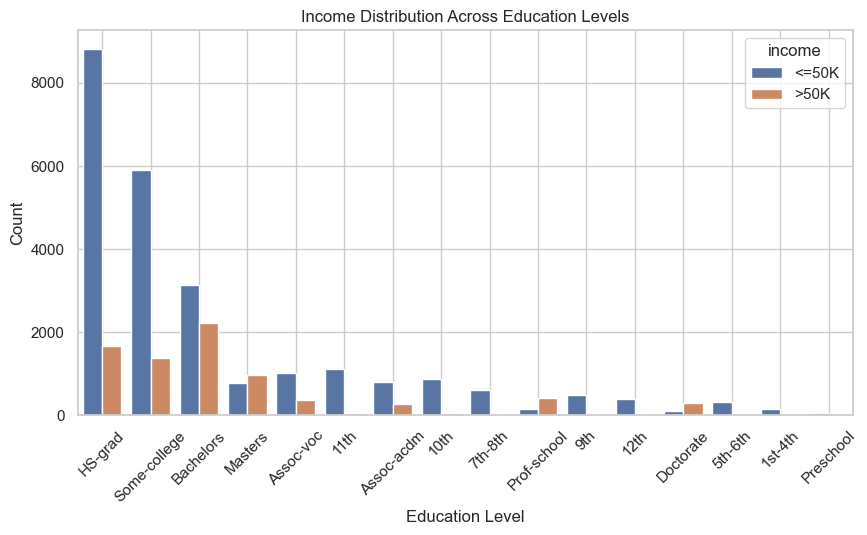

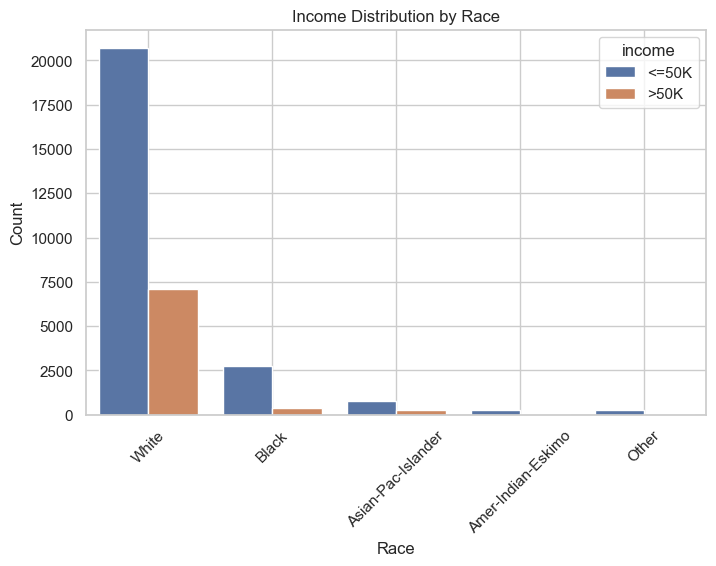

In [29]:
# Age distribution by income class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='age')
plt.title("Age Distribution by Income Class")
plt.xlabel("Income")
plt.ylabel("Age")
plt.grid(True)
plt.show()

# Hours worked per week by income class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title("Hours Worked per Week by Income Class")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.grid(True)
plt.show()

# Education level by income class
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education', hue='income', order=df['education'].value_counts().index)
plt.title("Income Distribution Across Education Levels")
plt.xticks(rotation=45)
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Race and income comparison
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='race', hue='income')
plt.title("Income Distribution by Race")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Race")
plt.grid(True)
plt.show()


## Feature Preprocessing Considerations

Before sending the data into machine learning models, the following features require special attention:

| **Feature**        | **Preprocessing Need**                                                                 |
|--------------------|----------------------------------------------------------------------------------------|
| `fnlwgt`           | ✔️ Retain and treat as a continuous numeric feature. Scale with others.               |
| `capital-gain`     | ⚠️ Skewed distribution with outliers. Consider log transformation or robust scaling.  |
| `capital-loss`     | ⚠️ Same as above — most values are 0, with a few very large ones.                     |
| `education-num`    | ✔️ Already numeric and clean. Scale directly.                                          |
| `hours-per-week`   | ✔️ Normal distribution, just scale.                                                    |
| `age`              | ✔️ Continuous, suitable for direct scaling.                                            |
| `workclass`        | ⚠️ Contains missing values. Handle before encoding.                                    |
| `occupation`       | ⚠️ Contains missing values. Handle before encoding.                                    |
| `native-country`   | ⚠️ Contains missing values. Handle before encoding.                                    |
| Categorical features (e.g., `education`, `marital-status`, `relationship`, `race`, `sex`) | ✔️ Clean but require encoding. One-hot encoding is suitable. |

### 📝 Summary

- Missing values must be handled before encoding or scaling.
- Skewed features (capital-gain/loss) require attention to avoid model distortion.
- All numerical features should be scaled.


## Data Cleaning and Splitting Strategy

To prepare the data for modeling while avoiding data leakage:

- We first **drop rows with missing values** from the dataset. This affects features like `workclass`, `occupation`, and `native-country`.
- Then we **split the cleaned dataset** into:
  - Training set (70%)
  - Validation set (15%)
  - Test set (15%)

Splitting is done **before any encoding or scaling**, so that transformations are fit only on the training set and applied to validation/test sets.


In [33]:
from sklearn.model_selection import train_test_split

# Step 1: Drop rows with missing values
df_clean = df.dropna()

# Step 2: Separate features and target
X = df_clean.drop("income", axis=1)
y = df_clean["income"]

# Step 3: train (70%) + temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")


Training set: (21113, 14)
Validation set: (4524, 14)
Test set: (4525, 14)


## Preprocessing Pipeline Setup

To properly prepare the dataset for machine learning models:

- We define a **ColumnTransformer** that applies:
  - `StandardScaler` to numerical features, to normalize the data
  - `OneHotEncoder` to categorical features, converting them into numeric binary columns

- We use `Pipeline` to cleanly organize preprocessing steps.
- This pipeline will be **fit on the training set only**, and then used to transform validation and test sets — avoiding data leakage.


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numeric and categorical columns
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

# Define transformers for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into a single preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


## Applying the Preprocessing Pipeline

At this step, we apply our preprocessing logic to the dataset splits:

- The `preprocessor` is **fit on the training data only** (`X_train`) to learn scaling parameters and one-hot encoding structure.
- The same preprocessor is then **used to transform** the validation and test sets (`X_val`, `X_test`).
- This ensures that the validation and test data are treated the same way without leaking information from them into the training process.

Additionally:
- The target column (`income`) is **converted from string to binary** format:
  - `>50K` → `1`
  - `<=50K` → `0`

This completes the core data preparation, and the processed data is now ready for training and evaluation.


In [35]:
# Fit on training set only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test sets using the fitted pipeline
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Encode the target variable to binary if needed
y_train = y_train.map({'>50K': 1, '<=50K': 0}) if y_train.dtype == 'object' else y_train
y_val = y_val.map({'>50K': 1, '<=50K': 0}) if y_val.dtype == 'object' else y_val
y_test = y_test.map({'>50K': 1, '<=50K': 0}) if y_test.dtype == 'object' else y_test

# Confirm shapes
print(f"X_train shape (after transform): {X_train_processed.shape}")
print(f"X_val shape: {X_val_processed.shape}")
print(f"X_test shape: {X_test_processed.shape}")


X_train shape (after transform): (21113, 104)
X_val shape: (4524, 104)
X_test shape: (4525, 104)


# Modeling and Evaluation

## Model 1: Logistic Regression

We start with Logistic Regression as a baseline classification model. It’s fast to train, interpretable, and provides a good performance benchmark for more complex models.

Evaluation will include:
- Accuracy
- Confusion Matrix
- Classification Report (Precision, Recall, F1-score)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train logistic regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_proce ssed, y_train)

# Predict on validation set
y_val_pred = logreg.predict(X_val_processed)

# Evaluate
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))


Validation Accuracy: 0.8514588859416445

Confusion Matrix:
 [[3150  213]
 [ 459  702]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.94      0.90      3363
           1       0.77      0.60      0.68      1161

    accuracy                           0.85      4524
   macro avg       0.82      0.77      0.79      4524
weighted avg       0.85      0.85      0.85      4524



## Model 2: Decision Tree Classifier

Decision Trees are flexible, non-linear classifiers that split the feature space into decision boundaries.  
They're useful for:
- Modeling complex relationships
- Understanding feature importance
- Visualizing decision logic (if the tree is small)

We'll evaluate the model using the validation set and standard classification metrics.


In [37]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_processed, y_train)

# Predict and evaluate on validation set
y_val_pred_dt = dtree.predict(X_val_processed)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_dt))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_dt))


Validation Accuracy: 0.8101237842617153

Confusion Matrix:
 [[2937  426]
 [ 433  728]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      3363
           1       0.63      0.63      0.63      1161

    accuracy                           0.81      4524
   macro avg       0.75      0.75      0.75      4524
weighted avg       0.81      0.81      0.81      4524



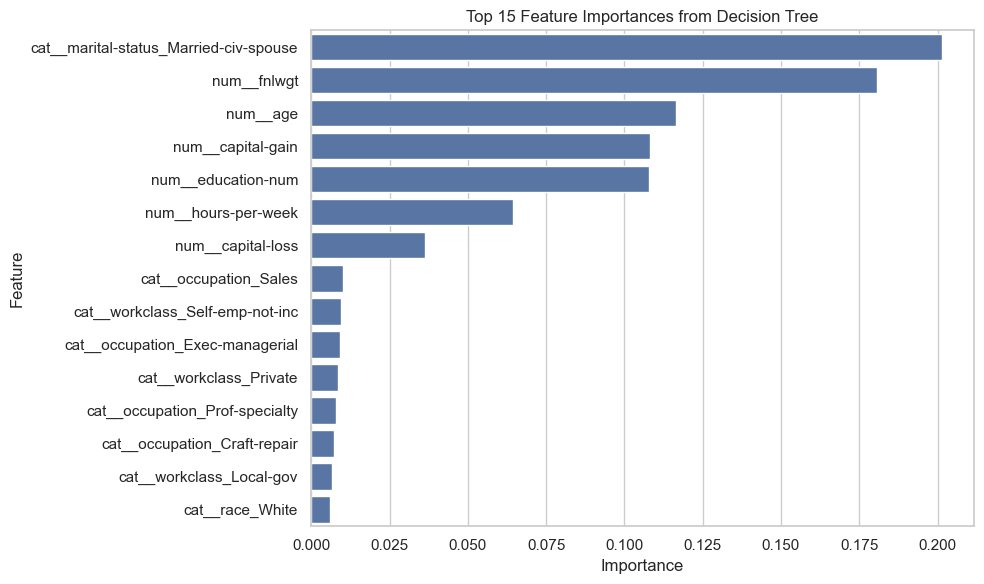

In [41]:
# Extract feature names from the encoder
# This handles the case where OneHotEncoder expands categorical features
feature_names = preprocessor.get_feature_names_out()

# Plot top 15 important features
importances = dtree.feature_importances_
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
top_features = importance_df.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances from Decision Tree")
plt.tight_layout()
plt.show()


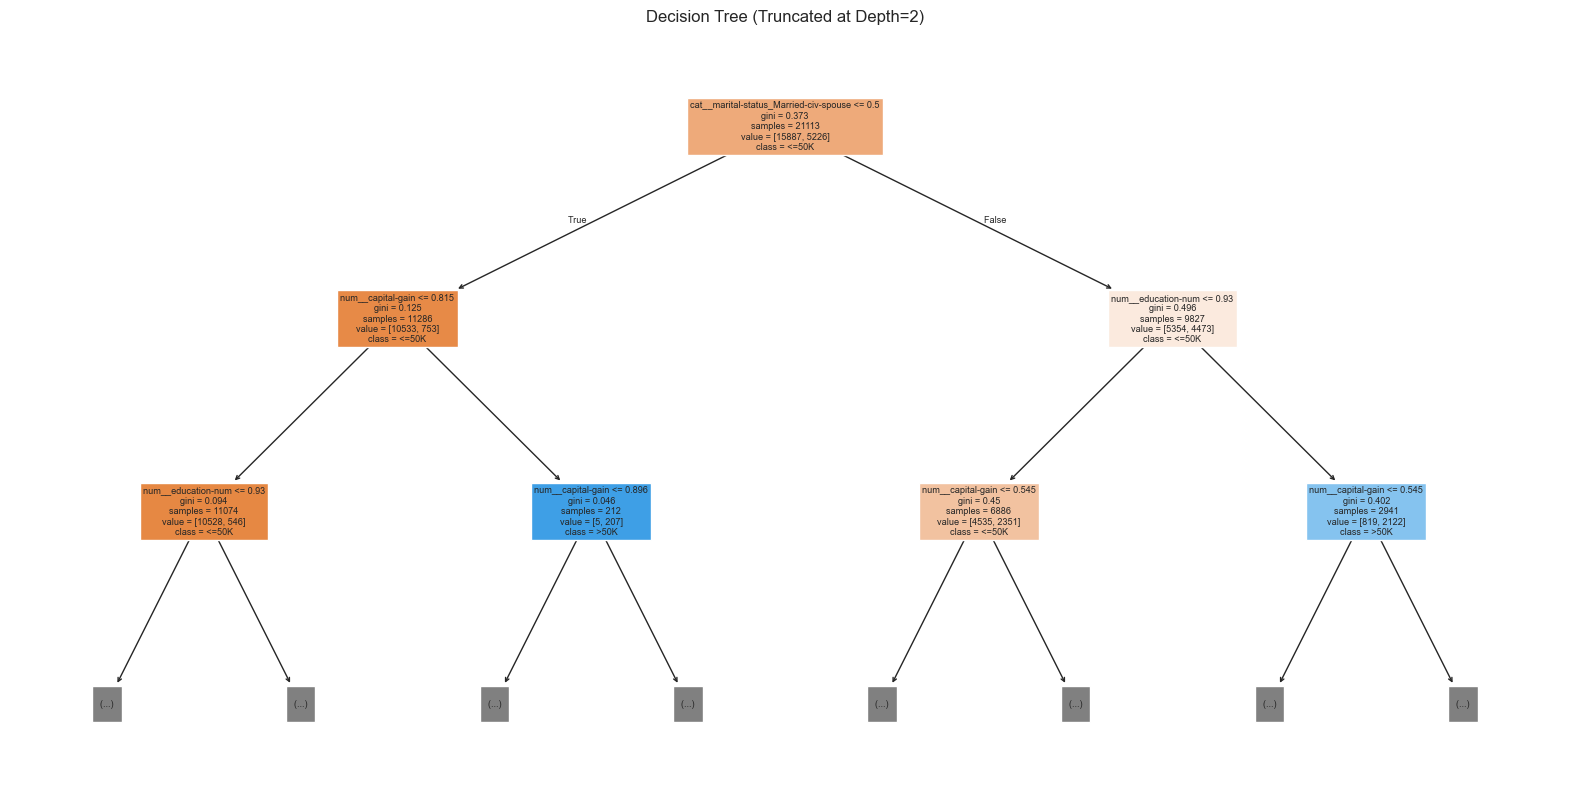

In [40]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dtree, max_depth=2, feature_names=feature_names, class_names=["<=50K", ">50K"], filled=True)
plt.title("Decision Tree (Truncated at Depth=2)")
plt.show()


## Model 3: Random Forest Classifier

Random Forest is an ensemble method that builds multiple decision trees and combines their predictions.  
It improves model stability and accuracy by reducing overfitting and variance.

We'll evaluate it using the same validation set and metrics as previous models.


In [42]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)

# Predict and evaluate on validation set
y_val_pred_rf = rf.predict(X_val_processed)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_rf))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_rf))


Validation Accuracy: 0.851237842617153

Confusion Matrix:
 [[3111  252]
 [ 421  740]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      3363
           1       0.75      0.64      0.69      1161

    accuracy                           0.85      4524
   macro avg       0.81      0.78      0.79      4524
weighted avg       0.85      0.85      0.85      4524



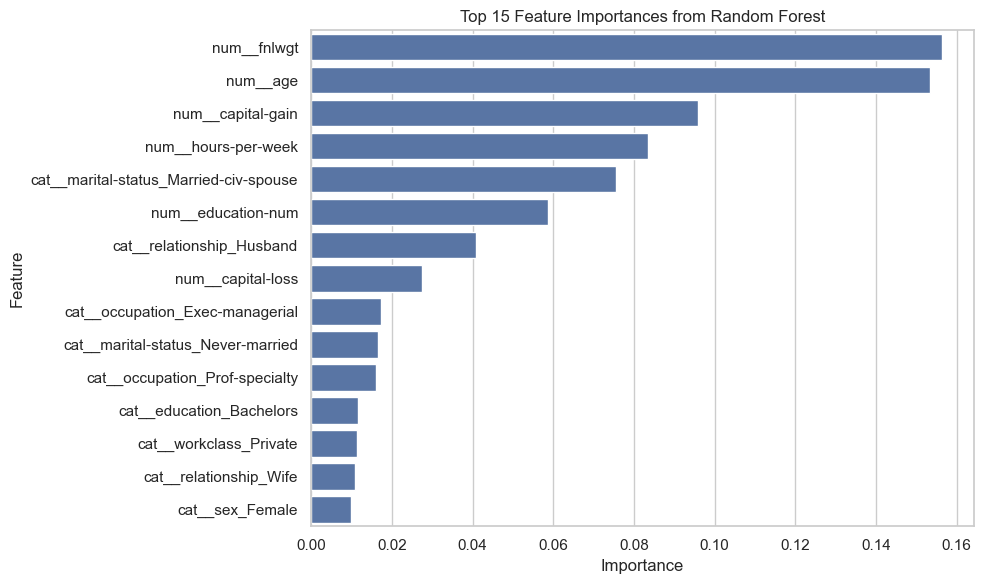

In [43]:
# Feature importances from Random Forest
rf_importances = rf.feature_importances_
rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
})

top_rf_features = rf_importance_df.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_rf_features, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances from Random Forest")
plt.tight_layout()
plt.show()


## Model 4: XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is a scalable, regularized gradient boosting framework that often outperforms other models on tabular datasets.  
It handles both numerical and categorical features (when encoded), and works well with imbalanced or noisy data.

We'll use it here to compare against previous models.


In [47]:
from xgboost import XGBClassifier

# XGBoost requires dense input
X_train_dense = X_train_processed.toarray()
X_val_dense = X_val_processed.toarray()

# Initialize and train
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_dense, y_train)

# Predict and evaluate
y_val_pred_xgb = xgb.predict(X_val_dense)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_xgb))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_xgb))


Validation Accuracy: 0.8693633952254642

Confusion Matrix:
 [[3157  206]
 [ 385  776]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91      3363
           1       0.79      0.67      0.72      1161

    accuracy                           0.87      4524
   macro avg       0.84      0.80      0.82      4524
weighted avg       0.87      0.87      0.87      4524



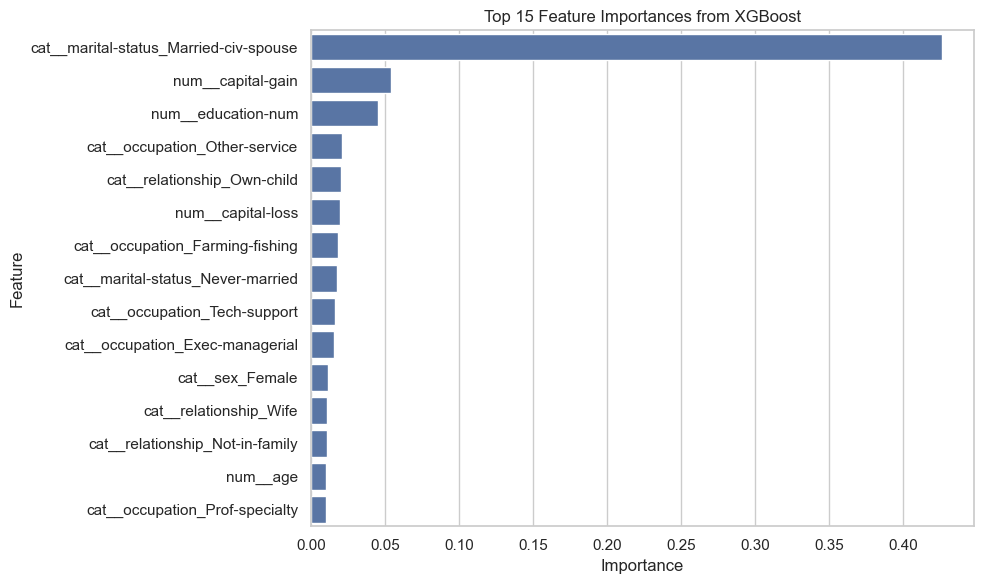

In [48]:
# Get feature importances
xgb_importances = xgb.feature_importances_
xgb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importances
})

# Sort and plot top 15
top_xgb_features = xgb_importance_df.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_xgb_features, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances from XGBoost")
plt.tight_layout()
plt.show()


## Model Comparison (Validation Set)

| Model                  | Validation Accuracy |
|------------------------|---------------------|
| Logistic Regression    | 85.15%              |
| Decision Tree          | 81.01%              |
| Random Forest          | 85.12%              |
| XGBoost                | **86.94%** ✅         |

**Conclusion**:  
XGBoost achieved the highest validation accuracy and will be selected as the final model to evaluate on the test set.


## Final Model Evaluation (Test Set)

We now evaluate the XGBoost model on the unseen test set to get a true estimate of its performance.


In [50]:
# Ensure test data is in dense format
X_test_dense = X_test_processed.toarray()

# Predict and evaluate
y_test_pred = xgb.predict(X_test_dense)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Test Accuracy: 0.8691712707182321

Confusion Matrix:
 [[3179  225]
 [ 367  754]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91      3404
           1       0.77      0.67      0.72      1121

    accuracy                           0.87      4525
   macro avg       0.83      0.80      0.82      4525
weighted avg       0.87      0.87      0.87      4525



# Conclusion

In this project, we explored the UCI Adult Income dataset to build machine learning models that predict whether an individual's income exceeds $50K per year based on demographic and employment attributes.

### 🔍 Key Steps:
- Conducted extensive data exploration and visualization
- Cleaned missing values and handled outliers
- Performed one-hot encoding for categorical variables and scaling for numerical features
- Split data into training, validation, and test sets (70% / 15% / 15%)
- Built and evaluated multiple classification models:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost

### 🏁 Results:
- **XGBoost** achieved the highest validation accuracy (**86.94%**) and was selected as the final model
- Final test accuracy confirms strong generalization performance (see previous cell for detailed metrics)

### ✅ Final Takeaways:
- Age, education level, hours worked per week, and marital status were consistently among the most important features.
- XGBoost provided a strong balance of accuracy and robustness for this binary classification task.
- With minimal tuning, strong performance was achieved — indicating the dataset is well-structured and predictable with the chosen features.

This concludes the end-to-end pipeline for income prediction based on census data.
